![imagen](fotos/IMAGEN_vinos-tinto.jpg)

# CALIDAD DEL VINO TINTO

## 1. DESCRIPCION

El conjunto de datos nos da información sobre el vino tinto portugués. A partir de propiedades fisico-químicas se va a intentar determinar la calidad del vino.

## 2. DATOS

Debido a cuestiones de privacidad y logística, solo se dispone de variables fisicoquímicas (insumos) y sensoriales (resultados)

El conjunto de datos utilizados proviene de un dataset alojado en Kaggle con el fin de determinar la calidad del vino tinto. Este conjunto de datos también está disponible en el repositorio de aprendizaje automático de la UCI, https://archive.ics.uci.edu/ml/datasets/wine+quality .

El archivo extraido de Kaggle es:

> winequality-red.csv

### 2.1 ANALISIS GENERAL DE LOS DATOS

Se analiza el dataset que hemos extraido de Kaggle.

En esta sección se importan las librerías necesarias para el análisis de los datos y se carga el dataset que hemos extraido de Kaggle sobre la calidad de vinos tintos.


### 2.1.1 IMPORTACION DE LIBRERIAS

In [1]:
import pandas as pd

In [2]:
# Visualización 
import matplotlib.pyplot as plt 
import seaborn as sns

### 2.1.2 CARGA DEL DATASET

In [3]:
df = pd.read_csv ("data/winequality-red.csv", sep=",")
df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


La función head( ) permite visualizar las primeras filas para entender la estructura de los datos.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Dimensiones del dataset:


In [6]:
df.shape

(1599, 12)

La función shape( ) nos devuelve el número de filas y de columnas del dataset.

Ahora se verifica si existen valores faltantes en el dataset:

In [7]:
df.isnull().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

No existen valores nulos en el dataset como también hemos visto con la función info( )

In [8]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


#### ANALIZANDO EL CONJUNTO DE DATOS  SE TIENE:

El análisis del conjunto del dataset nos permite verificar si existen problemas en la calidad de los datos.

- 1599 REGISTROS

- 12 COLUMNAS

- SIN VALORES NULOS

- VARIABLES NUMERICAS:

    - 11 VARIABLES FLOAT:
    
        - fixed acidity
    
        - volatile acidity

        - citric acid

        - residual sugar

        - chlorides

        - free sulfur dioxide

        - total sulfur dioxide

        - density

        - pH

        - sulphates

        - alcohol

    - 1 VARIABLE INT:

        - quality
    

Las COLUMNAS se dividen en:

- Variables fisicoquímicas:

    - fixed acidity  &rarr;  acidez fija
    - volatile acidity  &rarr;  acidez volátil
    - citric acid  &rarr;  ácido cítrico  
    - residual sugar  &rarr;  azúcar residual
    - chlorides  &rarr;  cloruros
    - free sulfur dioxide  &rarr;  dióxido de azufre libre
    - total sulfur dioxide  &rarr;  dióxido de azufre total
    - density  &rarr;  densidad
    - pH
    - sulphates  &rarr;  sulfatos
    - alcohol

- Variable sensorial:

    - quality  &rarr;  calidad 

## 3. MODIFICACIONES EN LOS DATOS

Como hemos visto antes en el apartado 2.1.2 nuestro dataset si tiene registros duplicados. Dichos registros se eliminan porque afectan al rendimiento de los modelos de Machine Learning.

In [9]:
# se eliminan registros duplicados
df_1 = df.drop_duplicates()

Las nuevas dimensiones de nuestro dataset:

In [10]:
df_1.shape

(1359, 12)

Se tiene en nuestro dataset:

- 1359 registros NO duplicados
- 12 columnas

Se pasa el dataset a español renombrando las columnas de la siguiente manera:

> - fixed acidity  &rarr;  acidez_fija
> - volatile acidity  &rarr;  acidez_volatil
> - citric acid  &rarr;  acido_citrico
> - residual sugar  &rarr;  azucar_resid
> - chlorides  &rarr; cloruros
> - free sulfur dioxide  &rarr;  dioxido_azufre_libre
> - total sulfur dioxide  &rarr;  dioxido_azufre_total
> - density  &rarr;  densidad
> - sulphates  &rarr;  sulfatos
> - quality  &rarr;  calidad


In [11]:
# Renombrar columnas en español
df_e = df_1.rename(columns={
    'fixed acidity': 'acidez_fija', 
    'volatile acidity': 'acidez_volatil',
    'citric acid': 'acido_citrico',
    'residual sugar': 'azucar_resid',
    'chlorides': 'cloruros',
    'free sulfur dioxide': 'dioxido_azufre_libre',
    'total sulfur dioxide': 'dioxido_azufre_total',
    'density': 'densidad',
    'sulphates': 'sulfatos',
    'quality' : 'calidad'})




In [12]:
df_e

,acidez_fija,acidez_volatil,acido_citrico,azucar_resid,cloruros,dioxido_azufre_libre,dioxido_azufre_total,densidad,pH,sulfatos,alcohol,calidad
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
5,7.4,0.660,0.00,1.8,0.075,13.0,40.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


Una vez limpio nuestro dataset se guarda en un nuevo DataFrame llamado df_e. De esta manera cuando necesitemos leer el DataFrame no es necesario realizar todas las operaciones de limpieza. y partimos de nuestro DataFrame limpio.

In [16]:
# Guarda el DataFrame limpio y traducido sin la columna de índices automáticos
df_e.to_csv("data_new/df_e.csv", index=False)

## 4. ANALISIS DE LAS VARIABLES

En el análisis de las variables se mira los valores entre los que se mueve la variable y el número de veces que se repiten los valores. También se analizan dichas variables mediante los gráficos:

- HISTOGRAMAS:

Un histograma muestra la distribución de frecuencia de una variable numérica. Permite identificar patrones en los datos, como concentración de observaciones, dispersión, asimetría y posibles valores atípicos.

- BOXPLOTS:

Los boxplots permiten analizar la dispersión y distribución de las variables numéricas mediante la mediana, el rango intercuartílico y la detección de valores atípicos. Los puntos alejados de los bigotes representan posibles outliers, mientras que la posición de la mediana y la forma de la caja ayudan a identificar asimetrías en la distribución de los datos.

### 4.1 ANALISIS UNIVARIABLE 

### 4.1.1 VARIABLE  $\Rightarrow$  fixed acidity  &rarr;  acidez fija

#### 4.1.2 VARIABLE  $\Rightarrow$  volatile acidity  &rarr;  acidez volátil

#### 4.1.3 VARIABLE  $\Rightarrow$   citric acid  &rarr;  ácido cítrico

#### 4.1.4 VARIABLE  $\Rightarrow$   residual sugar  &rarr;  azúcar residual

#### 4.1.5 VARIABLE  $\Rightarrow$   chlorides  &rarr;  cloruros

#### 4.1.6 VARIABLE  $\Rightarrow$   free sulfur dioxide  &rarr;  dióxido de azufre libre

#### 4.1.7 VARIABLE  $\Rightarrow$   total sulfur dioxide  &rarr;  dióxido de azufre total

#### 4.1.8 VARIABLE  $\Rightarrow$   density  &rarr;  densidad


#### 4.1.9 VARIABLE  $\Rightarrow$   pH

#### 4.1.10 VARIABLE  $\Rightarrow$   sulphates  &rarr;  sulfatos

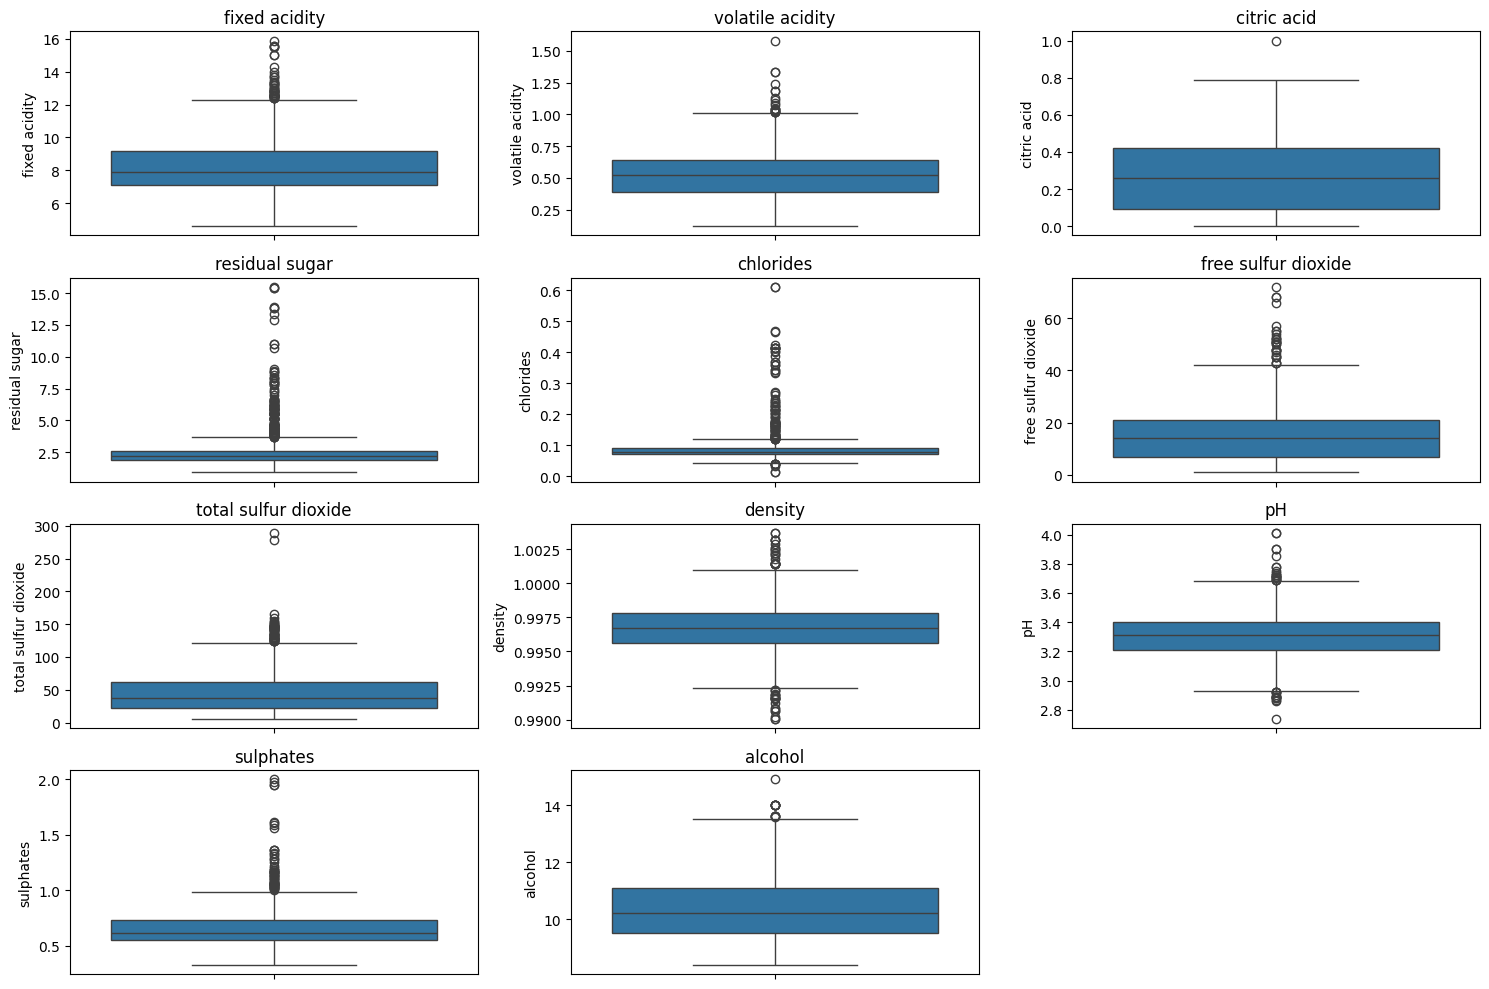

In [26]:
plt.figure(figsize=(15,10))

for i, column in enumerate(df.columns[:-1], 1):
    plt.subplot(4,3,i)
    sns.boxplot(y=df[column])
    plt.title(column)

plt.tight_layout()
plt.show()


#### 4.1.11 VARIABLE  $\Rightarrow$   alcohol

#### 4.1.12 VARIABLE  $\Rightarrow$   quality  &rarr;  calidad 

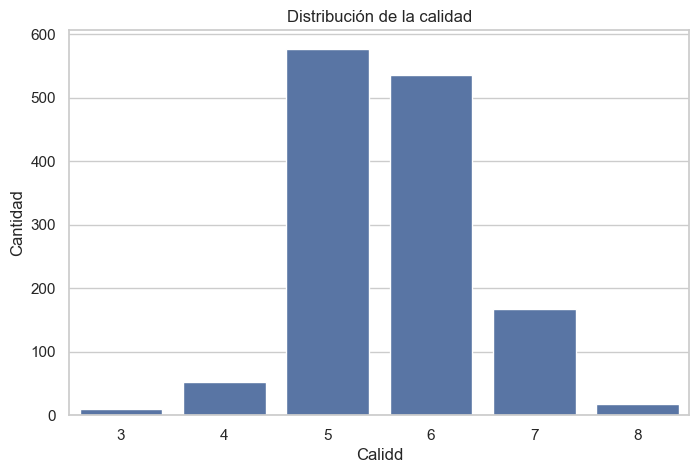

In [ ]:
plt.figure(figsize=(8,5))

sns.countplot(x='calidad', data=df_e)

plt.title('Distribución de la calidad')
plt.xlabel('Calidd')
plt.ylabel('Cantidad')

plt.show()

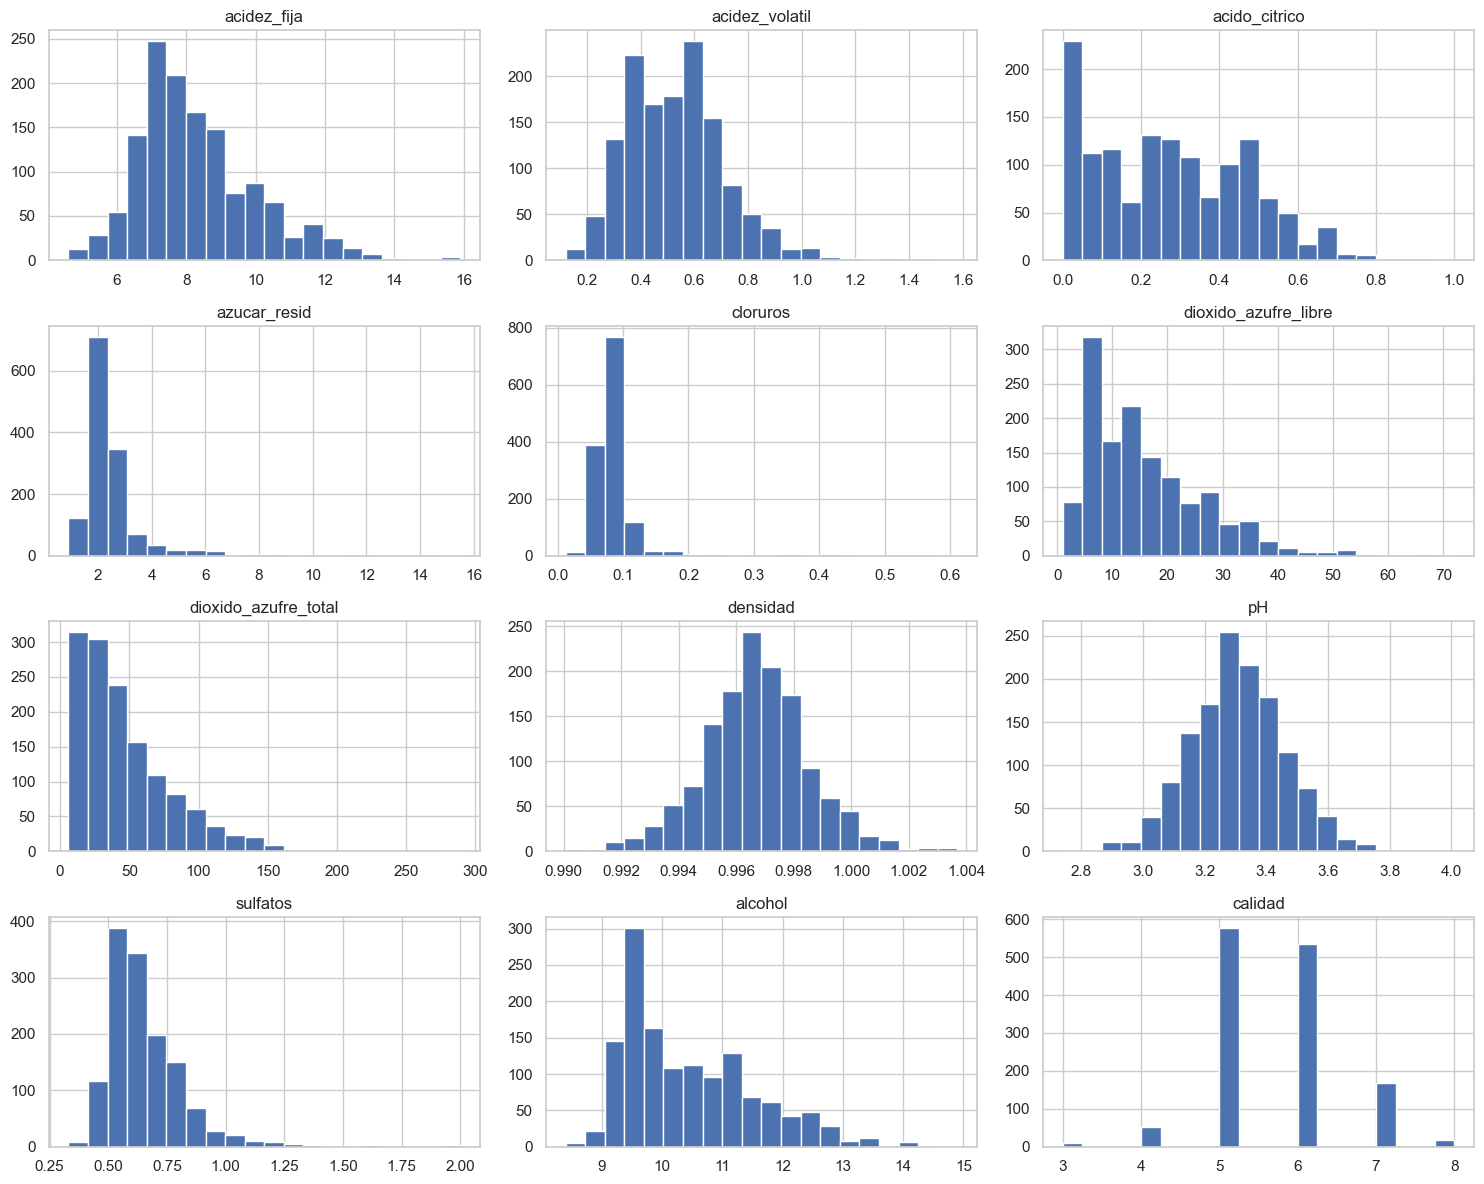

In [ ]:
df_e.hist(bins=20, figsize=(15,12)) 
plt.tight_layout() 
plt.show()

### 4.2 ANALISIS BIVARIADO

#### 4.2.1 CORRELACION

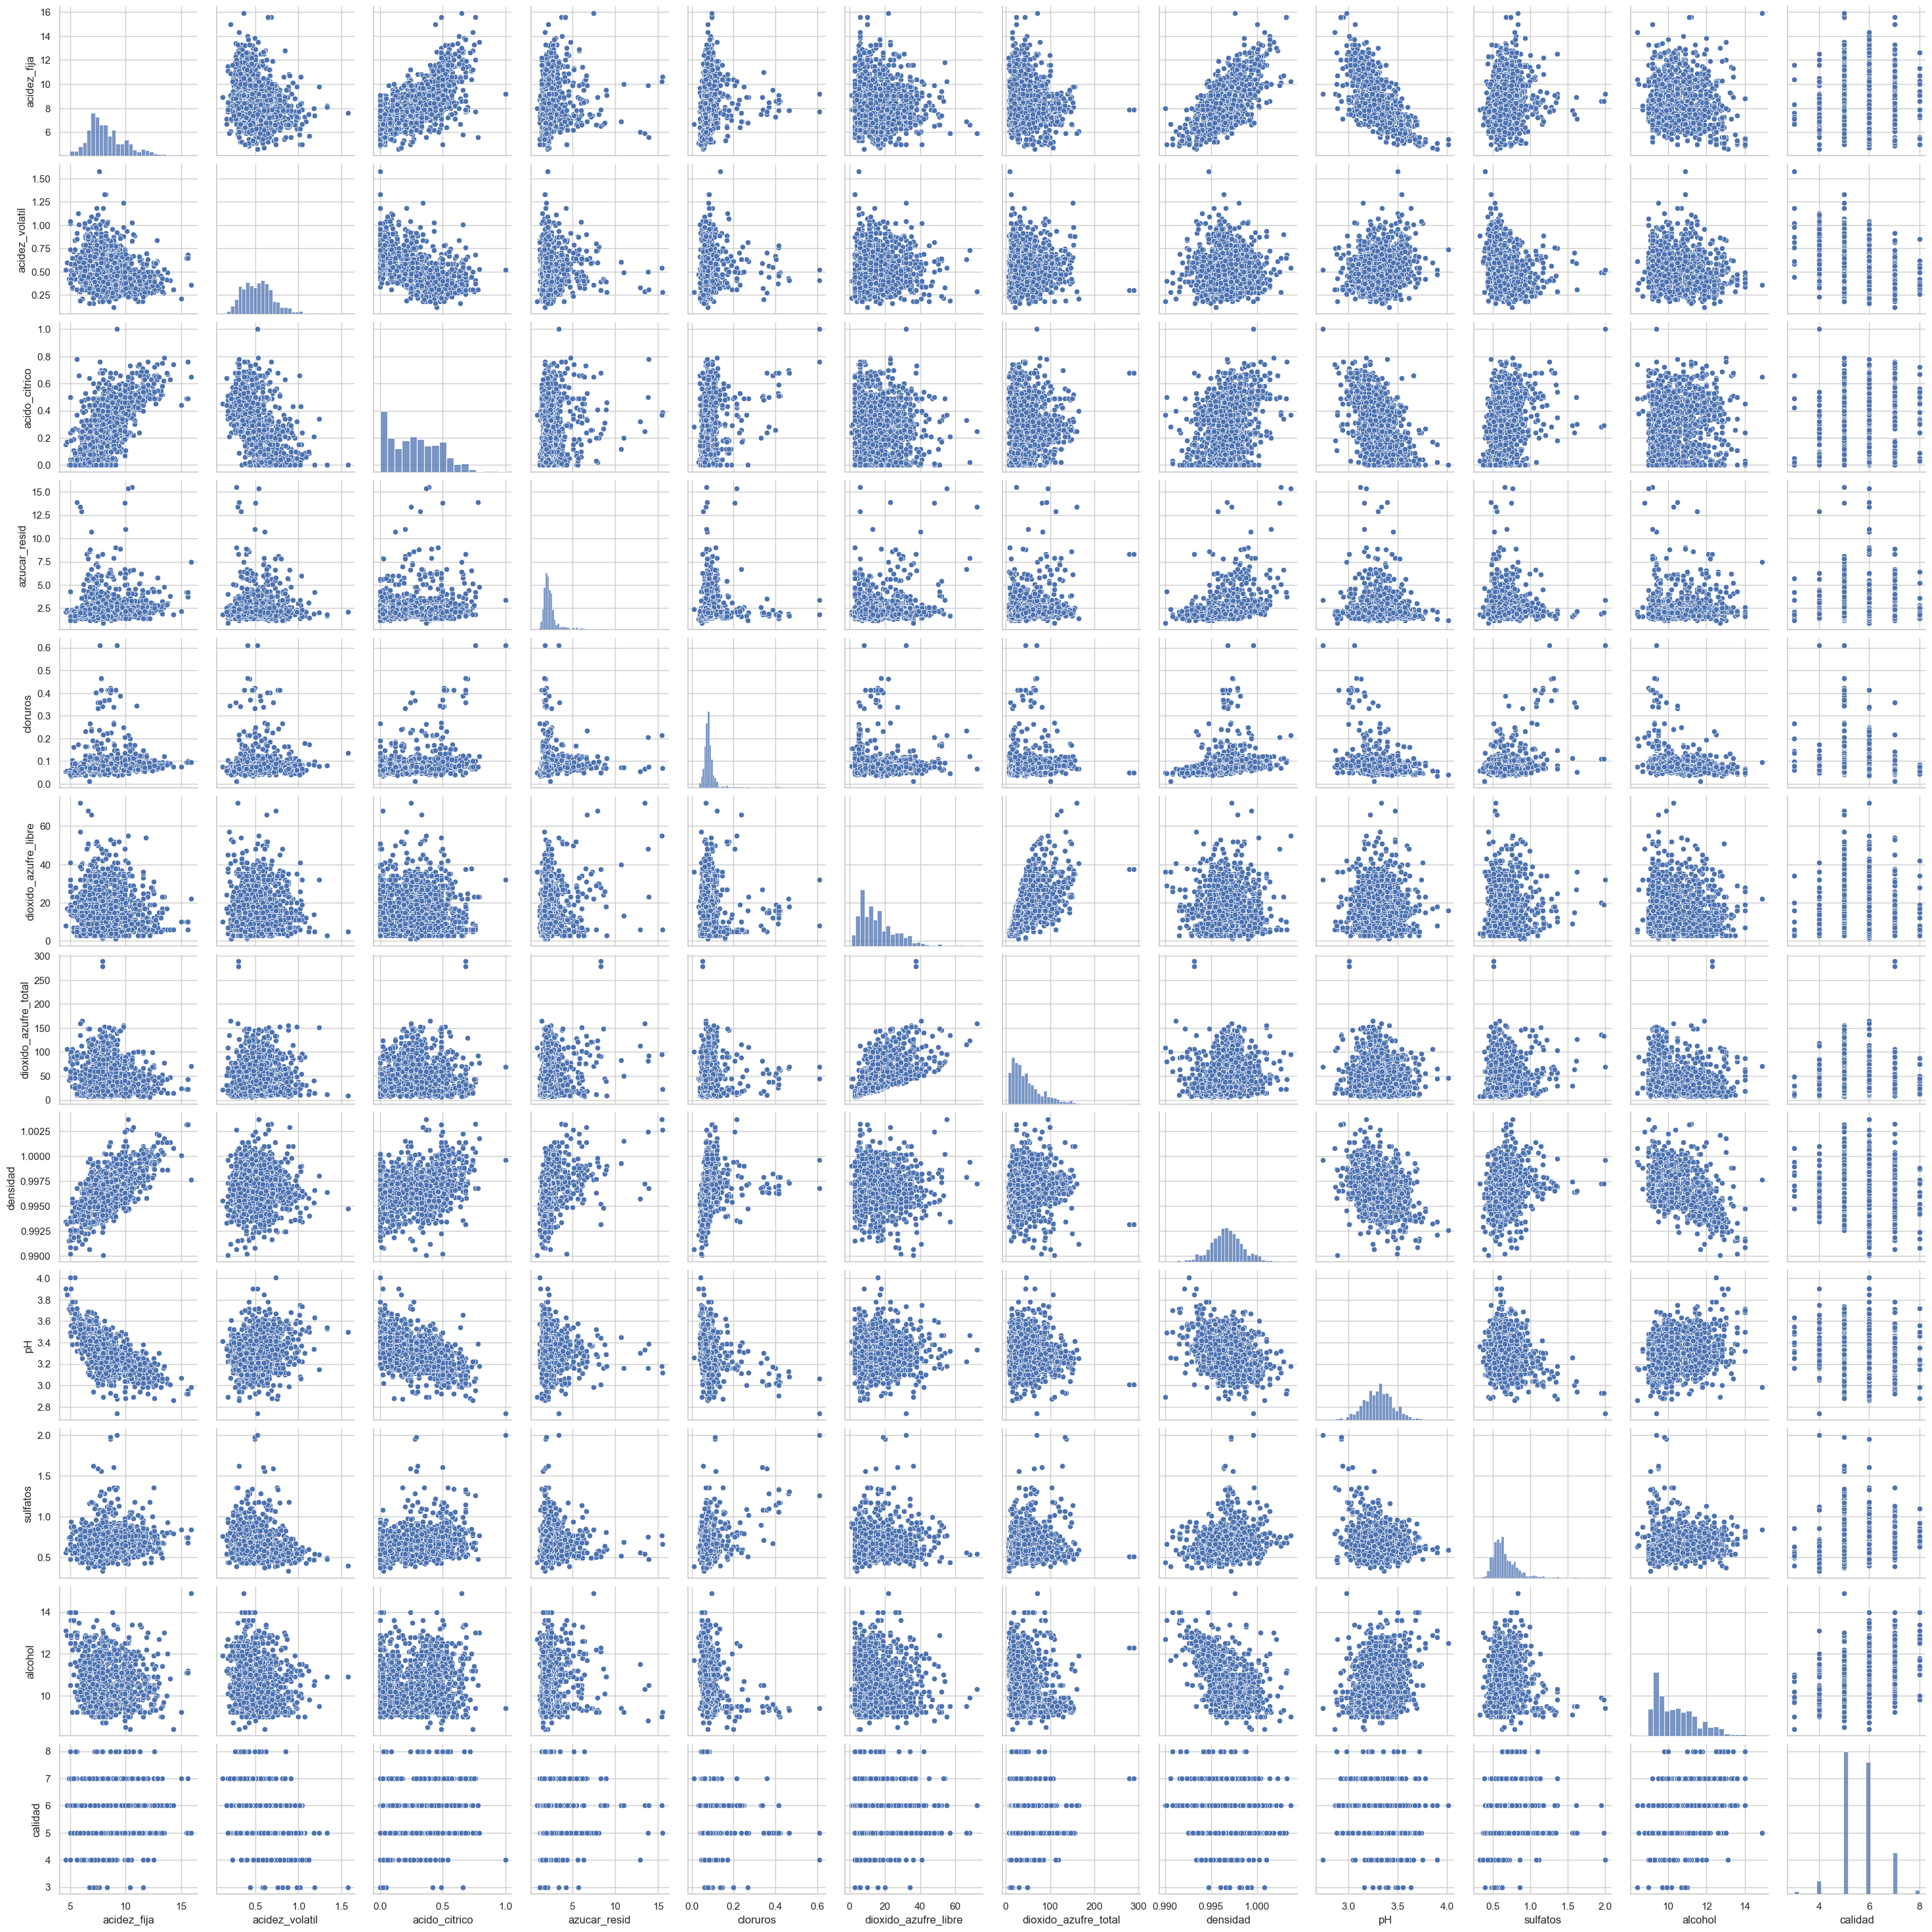

In [ ]:
sns.pairplot(df_e)

#### 4.2.2 MATRIZ DE CORRELACION

La matriz de correlación permite identificar relaciones entre variables.

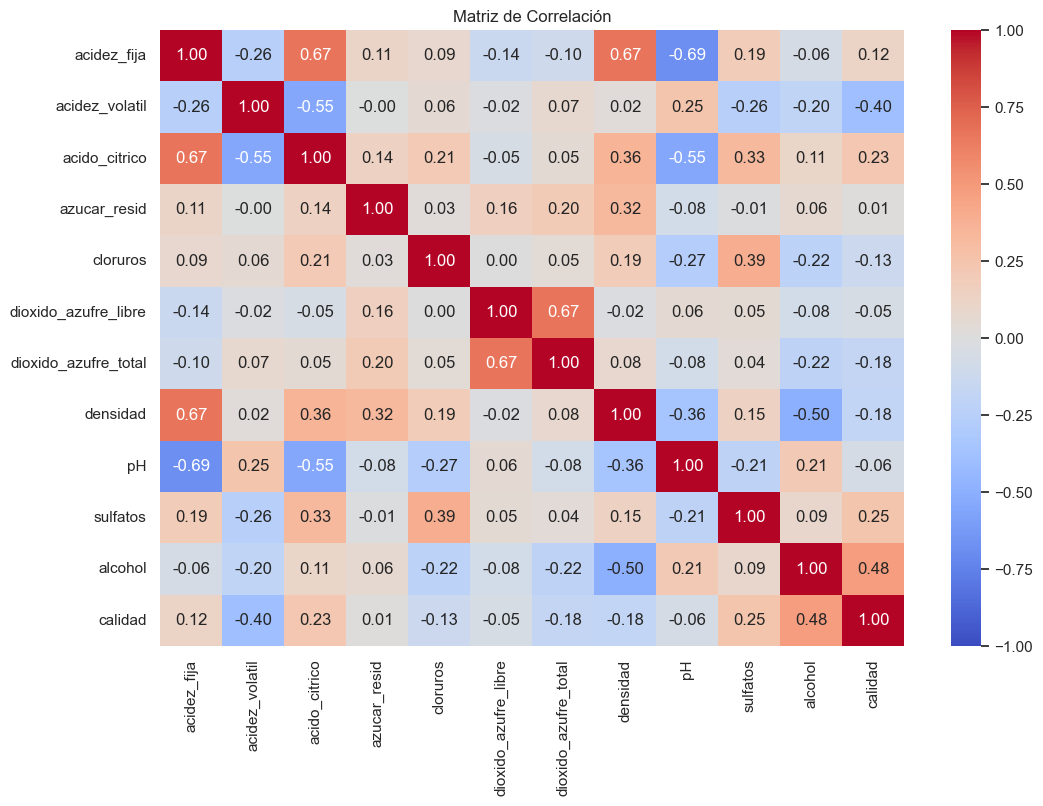

In [ ]:
# Matriz de correlación
plt.figure(figsize=(12,8))

correlation = df_e.corr()

sns.heatmap(correlation,
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            fmt='.2f')

plt.title('Matriz de Correlación')
plt.show()

Como se observa en la matriz de correlación las variables más relacionadas con la calidad son:


- la variable: ALCOHOL	&rarr;  tiene una relación: POSITIVA

- la variable: SULFATOS  &rarr;  tiene una relación: POSITIVA

- la variable: ACIDO CITRICO  &rarr; tiene una relación: POSITIVA

- la variable: ACIDEZ VOLATIL  &rarr;  tiene una relación: NEGATIVA

#### 4.2.3 RELACION ENTRE VARIABLES IMPORTANTES Y CALIDAD

##### 4.2.3.1 RELACION ENTRE ALCOHOL Y CALIDAD

Se analiza cómo influye el alcohol en la calidad del vino.

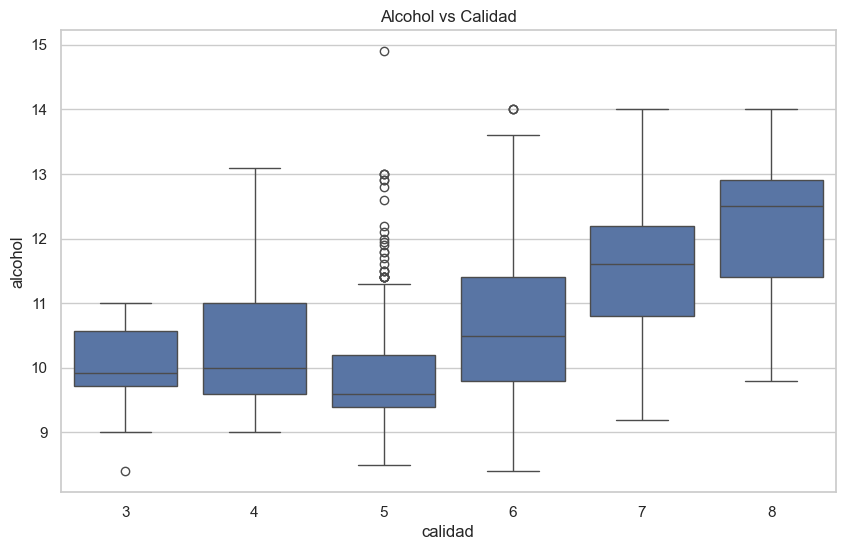

In [ ]:
sns.boxplot(x='calidad', y='alcohol', data=df_e)

plt.title('Alcohol vs Calidad')
plt.show()

Interpretación

Los vinos con mayor calidad tienden a tener mayor contenido alcohólico.

##### 4.2.3.2 RELACION ENTRE ACIDEZ VOLATIL Y CALIDAD

Se estudia la relación entre acidez volátil y calidad.

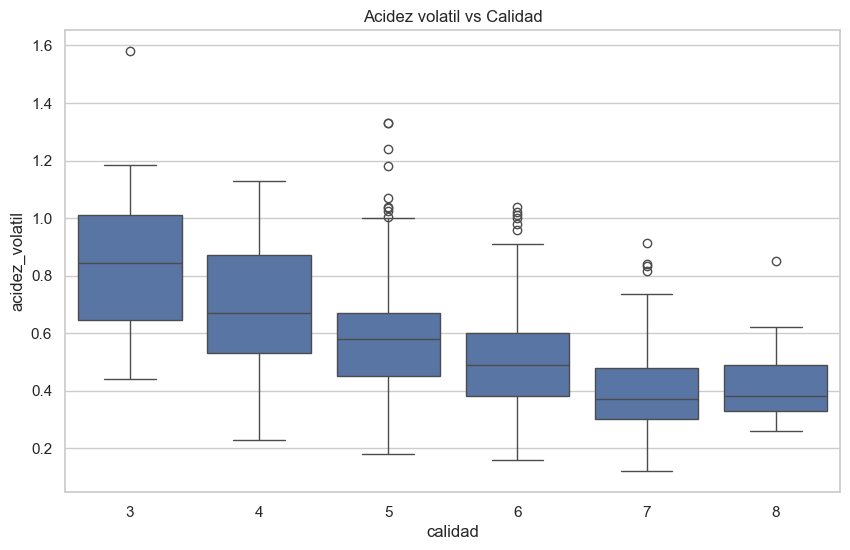

In [ ]:
sns.boxplot(x='calidad', y='acidez_volatil', data=df_e)

plt.title('Acidez volatil vs Calidad')
plt.show()

Interpretación

Los vinos de menor calidad presentan niveles más altos de acidez volátil.

##### 4.2.3.3 RELACION ENTRE SULFATOS Y CALIDAD

Se estudia la relación entre los sulfatos y calidad.

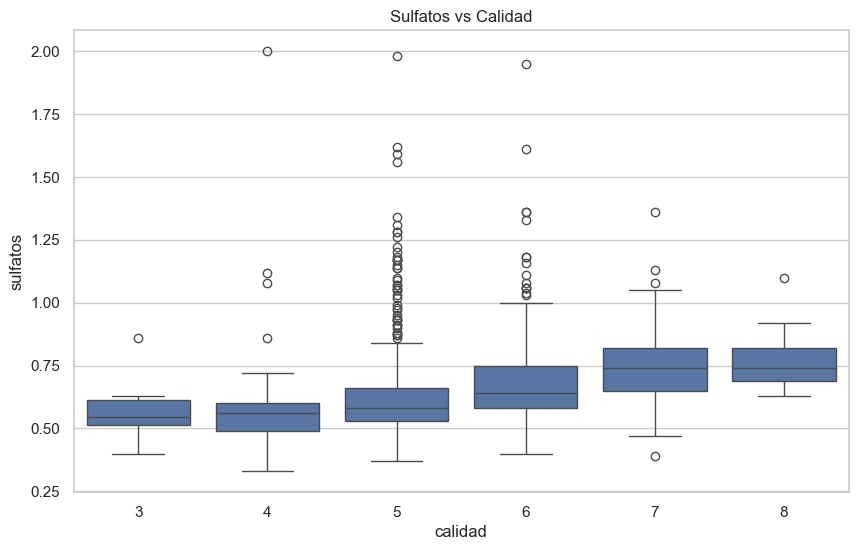

In [ ]:
sns.boxplot(x='calidad', y='sulfatos', data=df_e)

plt.title('Sulfatos vs Calidad')
plt.show()

Interpretación

Los vinos con mejores puntuaciones suelen presentar mayores niveles de sulfatos.

##### 4.2.3.4 RELACION ENTRE ACIDO CITRICO Y CALIDAD

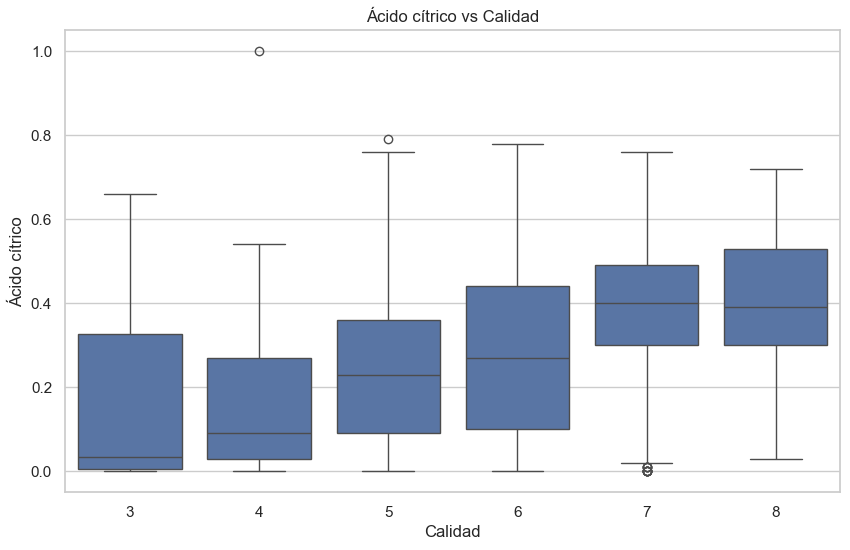

In [ ]:
#plt.figure(figsize=(8,5))

sns.boxplot(x='calidad',
            y='acido_citrico',
            data=df_e)

plt.title('Ácido cítrico vs Calidad')
plt.xlabel('Calidad')
plt.ylabel('Ácido cítrico')

plt.show()

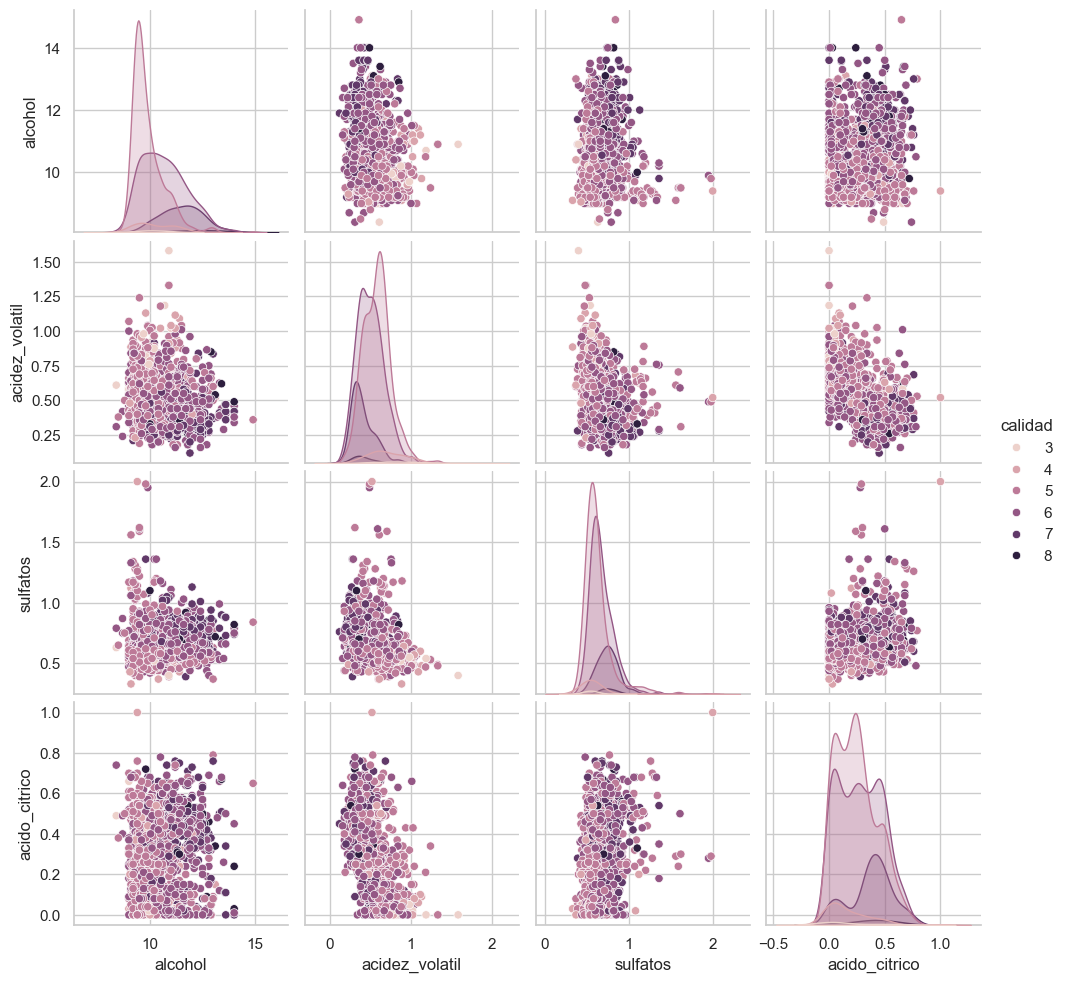

In [ ]:
# Pairplot de variables importantes
vbles_imp = [
    'alcohol',
    'acidez_volatil',
    'sulfatos',
    'acido_citrico',
    'calidad'
]

sns.pairplot(df_e[vbles_imp],
             hue='calidad')

plt.show()

<Axes: xlabel='calidad', ylabel='alcohol'>

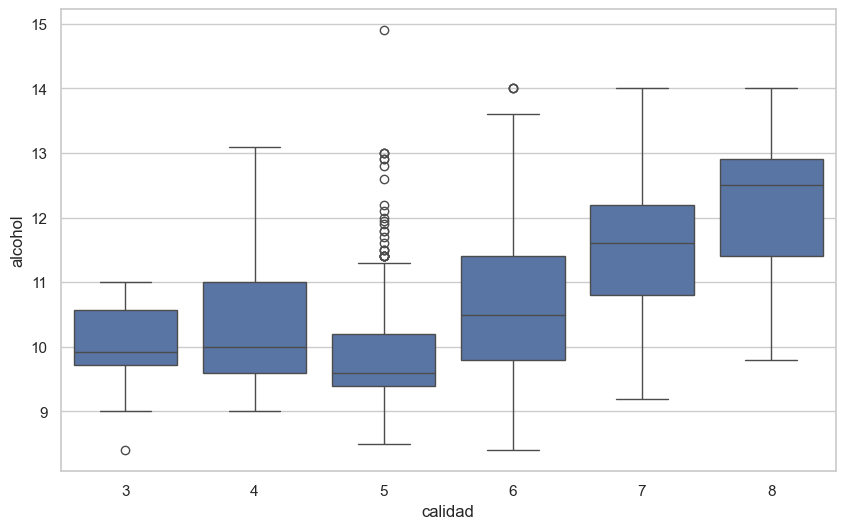

In [ ]:
sns.boxplot(x='calidad', y='alcohol', data=df_e)

## 5. MODELOS


### PROBANDO MODELOS


### 5.1 MODELO DE REGRESION LINEAL

1. Objetivo

    Se aplica un modelo de Regresión Lineal para predecir la variable "calidad" del vino utilizando las variables químicas del dataset. El objetivo será predecir directamente el valor numérico de la calidad del vino.


In [13]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler



2. Preparación de datos

    Separar variables predictoras (X) y la variable objetivo (y).

In [ ]:
# Variables independientes

X = df_e.drop(columns=['calidad'])


# Variable objetivo
y = df_e['calidad']


3. División de los datos en un conjunto de entrenamiento (TRAIN - 85%) y de prueba (TEST - 15%)

In [15]:
from sklearn.model_selection import train_test_split

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

4. Escalado de variables

    Aunque la regresión lineal no siempre lo requiere, es recomendable escalar las variables para mejorar la estabilidad numérica.


In [17]:
from sklearn.preprocessing import StandardScaler


In [18]:
# Crear escalador
scaler = StandardScaler()

# Escalar entrenamiento
X_train_scaled = scaler.fit_transform(X_train)

# Escalar test
X_test_scaled = scaler.transform(X_test)

5. Crear e inicializar el modelo de Regresión Lineal

In [19]:
from sklearn.linear_model import LinearRegression


In [20]:
# Crear modelo
lr = LinearRegression()

6. Entrenar el modelo con los datos de entrenamiento

In [21]:
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


7. Realizar predicciones usando el conjunto de prueba

In [22]:
y_pred = lr.predict(X_test_scaled)

In [23]:
# Mostrar primeras predicciones
print(y_pred[:10])

[5.24977159 5.81516147 6.36196267 5.13715707 5.21330258 6.7983219
 5.7046497  4.82633065 5.83483853 5.71836816]


8. Evaluar el rendimiento del modelo

    Se evalua el modelo mediante las métricas de regresión.

In [24]:
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, root_mean_squared_error, r2_score

In [27]:
print(f"MAE:  {mean_absolute_error(y_test, y_pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred):.4f}")
print(f"MSE:  {mean_squared_error(y_test, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y_test, y_pred):.4f}")
print(f"r2:   {r2_score(y_test, y_pred):.4f}")

MAE:  0.4909
MAPE: 0.0972
MSE:  0.4113
RMSE: 0.6413
r2:   0.3784


9. Explicación de las métricas

Estos resultados nos indican que el modelo de Regresión Lineal funciona de manera moderada, no excelente, para predecir la calidad del vino.

- MAE  &rarr;  Mean Absolute Error o Error Absoluto Medio

    MAE = 0.4999  

    El modelo se equivoca en ±0.49 puntos de calidad.

- MAPE  &rarr;  Mean Absolute Percentage Error o Error Porcentual Absoluto Medio

    Es una métrica que mide el tamaño del error del modelo en términos de porcentaje.

    MAPE = 0.0972

    El modelo tiene aproximadamente 9.72% de error promedio. Las predicciones se desvian un 9.72 % respecto al valor real. Valor aceptable para este dataset.

- MSE  &rarr;  Mean Squared Error o Error Cuadrático Medio

    MSE = 0.4113

    Penaliza mucho los errores grandes, en este caso el valor no es alto lo que indica que no hay demasiadas predicciones extremadamente malas.


- RMSE  &rarr;  Root Mean Squared Error o Raíz del Error Cuadrático Medio

    RMSE = 0.6413

    El error típico del modelo es aproximadamente ±0.64 puntos de calidad.

    Se compara con MAE, como el RMSE es más alto existen algunos errores grandes que el modelo penaliza más.

- R²  &rarr;  R2 Score

    R² = 0.3784 
    El modelo explica aproximadamenten el 37.84% de la variación en la calidad del vino.

    El modelo captura parte importante del patron pero deja mucha variabilidad sin explicar.




EN RESUMEN:

- Errores relativamente bajos
- Predicciones razonables
- Solo explica el 37.84 % de la calidad




El modelo de Regresión Lineal obtuvo un MAE de 0.4909 y un RMSE de 0.6413, lo que indica que las predicciones presentan errores moderados respecto a la calidad real del vino. El MAPE de 9.72% muestra que el error porcentual promedio es relativamente bajo. Sin embargo, el R² = 0.3784 indica que el modelo solo logra explicar aproximadamente el 37.84% de la variabilidad de la calidad del vino, lo que sugiere que existen relaciones en los datos que la regresión lineal no consigue modelar completamente.



9. ANALISIS DE LOS COEFICIENTES

In [25]:
#  Ver la importancia de cada característica (Coeficientes)
coeficientes = pd.DataFrame({'Característica': X.columns, 'Coeficiente': lr.coef_})
coeficientes = coeficientes.sort_values(by='Coeficiente', ascending=False)

print("IMPACTO DE CADA VARIABLE EN LA CALIDAD:")
print(coeficientes.to_string(index=False))

IMPACTO DE CADA VARIABLE EN LA CALIDAD:
      Característica  Coeficiente
             alcohol     0.334650
            sulfatos     0.146947
dioxido_azufre_libre     0.045308
            densidad     0.022351
        azucar_resid     0.005158
         acidez_fija    -0.027990
       acido_citrico    -0.030769
                  pH    -0.105617
            cloruros    -0.106513
dioxido_azufre_total    -0.116459
      acidez_volatil    -0.188312


El resultado anterior nos dice las variables que aumentan o disminuyen la calidad del vino y cuánto influyen.

- Alcohol = +0.334 

    Es la variable MÁS importante del modelo.

    A mayor contenido de alcohol, mayor calidad predicha del vino.


- Sulfatos = +0.147

    Segunda variable positiva más importante.

    Niveles más altos de sulfatos se relacionan con mejor calidad.

    Los sulfatos ayudan:

    - estabilidad
    - conservación
    - sabor

Tienen poca influencia en la predicción:

- dióxido azufre libre	+0.045
- densidad	+0.022
- azúcar residual	+0.005


Variables que DISMINUYEN la calidad:

- acidez volátil	-0.188
- dióxido azufre total	-0.116
- cloruros	-0.106
- pH	-0.105

   * Acidez volátil = -0.188

        Es la variable negativa MÁS importante.

        Cuando aumenta la acidez volátil, la calidad disminuye.

        Puede tener sentido porque la acidez volátil puede generar sabores desagradables y olor a vinagre. 

        Por lo que a mucha acidez volátil → peor vino.



    * Dióxido de azufre total = -0.116

        Concentraciones altas de dióxido de azufre total se relacionan con menor calidad.

    * Cloruros = -0.106

        Altos niveles de salinidad/cloruros empeoran la calidad.

    * pH = -0.105

        Valores altos de pH reducen ligeramente la calidad.



Al escalar los datos los coeficientes NO están en unidades originales, pero

- Coeficiente grande significa mayor influencia

- Coeficiente pequeño significa poca influencia
Conclusión global del modelo

##### CONCLUSION GLOBAL DEL MODELO SOBRE LAS VARIABLES: 

Mejora calidad del vino:

✅ alcohol

✅ sulfatos

Empeora calidad del vino:

❌ acidez volátil

❌ exceso de dióxido de azufre

❌ cloruros


10. Visualización de predicciones

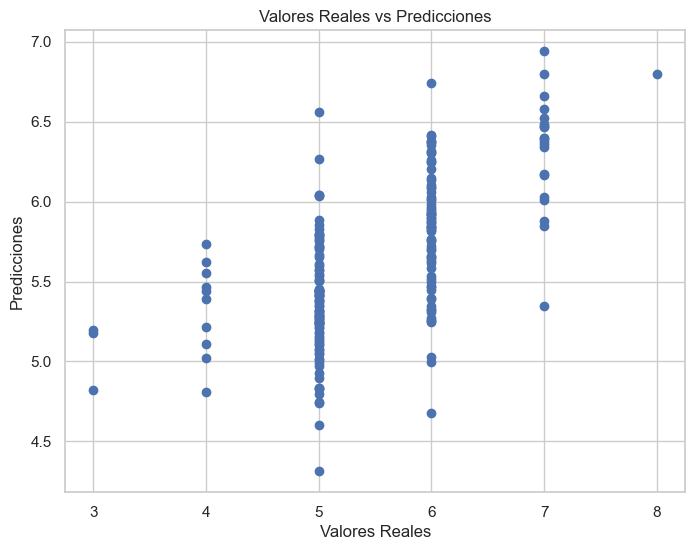

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

plt.xlabel("Valores Reales")
plt.ylabel("Predicciones")

plt.title("Valores Reales vs Predicciones")

plt.show()

El gráfico de valores reales vs predicciones muestra que el modelo de regresión lineal logra capturar parcialmente la tendencia general de la calidad del vino, ya que las predicciones aumentan conforme aumentan los valores reales. Sin embargo, las predicciones se concentran principalmente entre valores medios, mostrando dificultades para estimar correctamente las calidades extremas. Además, la dispersión observada para un mismo valor real indica que el modelo presenta errores moderados y no consigue explicar completamente la variabilidad presente en los datos. Esto sugiere que la relación entre las variables químicas y la calidad del vino no es completamente lineal.

11. Conclusión

    La regresión lineal permite modelar la relación entre las propiedades químicas del vino y su calidad mediante una combinación lineal de variables predictoras. Aunque ofrece una interpretación sencilla y rápida, su rendimiento puede verse limitado debido a la complejidad y no linealidad presente en los datos del dataset de vinos.

#### 5.2 OTROS MODELOS

Logistic Regression


## AGRADECIMIENTOS

P. Cortez, A. Cerdeira, F. Almeida, T. Matos y J. Reis. Modelado de preferencias de vino mediante minería de datos a partir de propiedades fisicoquímicas. En Decision Support Systems, Elsevier, 47(4):547-553, 2009.


## BIBLIOGRAFIA

Publicación:

P. Cortez, A. Cerdeira, F. Almeida, T. Matos y J. Reis. Modelado de preferencias de vino mediante minería de datos a partir de propiedades fisicoquímicas.
En Decision Support Systems, Elsevier, 47(4):547-553, 2009.